In [1]:
import numpy as np
import pandas as pd
import joblib
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt


In [2]:
data = pd.read_csv('Sales2.csv')
data['Date'] = pd.to_datetime(data['Date'])
data = data.groupby(['Date','Item Purchased'])['Sales'].sum()
data = pd.DataFrame(data, columns=['Sales'])

data=data.reset_index()
data = data.set_index('Date')

In [3]:
true_item=['Skirt']
data = data.loc[data['Item Purchased'].isin(true_item)]

import copy
dataconcate=copy.copy(data)

scaler = MinMaxScaler()
data['Sales'] = scaler.fit_transform(data['Sales'].values.reshape(-1, 1))
data.head(5)

,Item Purchased,Sales
Date,,
2023-01-01,Skirt,0.055556
2023-01-02,Skirt,0.222222
2023-01-04,Skirt,0.111111
2023-01-06,Skirt,0.111111
2023-01-08,Skirt,0.055556


In [4]:
train_size = int(len(data) * 0.7)
train_data, test_data = data[:train_size], data[train_size:]

def create_sequences(data, sequence_length):
    sequences = []
    for i in range(len(data) - sequence_length):
        sequence = data[i:i+sequence_length]
        target = data[i+sequence_length:i+sequence_length+1]
        sequences.append((sequence, target))
    return sequences

sequence_length = 10
train_sequences = create_sequences(train_data['Sales'], sequence_length)
test_sequences = create_sequences(test_data['Sales'], sequence_length)

X_train, y_train = np.array([seq[0] for seq in train_sequences]), np.array([seq[1] for seq in train_sequences])
X_test, y_test = np.array([seq[0] for seq in test_sequences]), np.array([seq[1] for seq in test_sequences])

# Build the LSTM model
import keras
from keras.models import Sequential
from keras.layers import LSTM, Dense
model = Sequential()
model.add(LSTM(100, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')


In [5]:
model.fit(X_train, y_train, epochs=50, batch_size=32)
train_predictions = model.predict(X_train)
test_predictions = model.predict(X_test)

Epoch 1/50
2/2 [==============================] - 5s 27ms/step - loss: 0.1152
Epoch 2/50
2/2 [==============================] - 0s 18ms/step - loss: 0.1045
Epoch 3/50
2/2 [==============================] - 0s 21ms/step - loss: 0.0941
Epoch 4/50
2/2 [==============================] - 0s 18ms/step - loss: 0.0852
Epoch 5/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0759
Epoch 6/50
2/2 [==============================] - 0s 16ms/step - loss: 0.0675
Epoch 7/50
2/2 [==============================] - 0s 15ms/step - loss: 0.0590
Epoch 8/50
2/2 [==============================] - 0s 19ms/step - loss: 0.0509
Epoch 9/50
2/2 [==============================] - 0s 16ms/step - loss: 0.0436
Epoch 10/50
2/2 [==============================] - 0s 16ms/step - loss: 0.0378
Epoch 11/50
2/2 [==============================] - 0s 13ms/step - loss: 0.0338
Epoch 12/50
2/2 [==============================] - 0s 17ms/step - loss: 0.0331
Epoch 13/50
2/2 [==============================] - 0s 15ms/st

In [6]:
# Inverse transform the scaled predictions to get actual sales values
train_predictions = scaler.inverse_transform(train_predictions)
test_predictions = scaler.inverse_transform(test_predictions)


In [7]:

train_rmse = np.sqrt(mean_squared_error(y_train, train_predictions))
test_rmse = np.sqrt(mean_squared_error(y_test, test_predictions))

print("Train RMSE:", train_rmse)
print("Test RMSE:", test_rmse)
print(test_predictions)

Train RMSE: 6.118637211746176
Test RMSE: 5.738521494869951
[[6.008065 ]
 [5.9552765]
 [5.925152 ]
 [5.8074923]
 [5.75783  ]
 [5.8564873]
 [6.10551  ]
 [6.1762786]
 [6.2548637]
 [6.0798035]
 [5.85573  ]
 [5.830354 ]]


In [8]:
import tensorflow as tf
# Predict sales for future time steps
time_steps = sequence_length
future_time_steps = 60
future_data = data['Sales'].values[-time_steps:].reshape(1, -1, 1)
future_data = future_data.reshape(1, time_steps, 1)
future_predictions = []

for _ in range(future_time_steps):
    next_prediction = model.predict(tf.convert_to_tensor(future_data))
    future_predictions.append(next_prediction[0, 0])
    future_data = np.append(future_data[:, 1:, :], next_prediction.reshape(1, 1, 1), axis=1)

# Inverse transform the future predictions
future_predictions = scaler.inverse_transform(np.array(future_predictions).reshape(-1, 1))

# Generate future timestamps
last_timestamp = data.index[-1]
future_timestamps = pd.date_range(start=last_timestamp, periods=future_time_steps+1, freq=data.index.freq)



1/1 [==============================] - 0s 50ms/step


In [9]:
print(future_predictions)

[[6.440856 ]
 [6.602061 ]
 [6.714528 ]
 [6.694023 ]
 [6.520376 ]
 [6.623808 ]
 [6.7004166]
 [6.7495003]
 [6.796373 ]
 [6.933316 ]
 [6.4816065]
 [6.4854336]
 [6.4815435]
 [6.473556 ]
 [6.465484 ]
 [6.462    ]
 [6.455664 ]
 [6.44748  ]
 [6.437569 ]
 [6.4272585]
 [6.411448 ]
 [6.4092164]
 [6.406727 ]
 [6.4042454]
 [6.4019613]
 [6.3998938]
 [6.397902 ]
 [6.396083 ]
 [6.394476 ]
 [6.393143 ]
 [6.392069 ]
 [6.391446 ]
 [6.390874 ]
 [6.3903656]
 [6.389922 ]
 [6.38954  ]
 [6.389212 ]
 [6.3889394]
 [6.3887134]
 [6.3885317]
 [6.388385 ]
 [6.3882675]
 [6.3881664]
 [6.3880787]
 [6.3880076]
 [6.387947 ]
 [6.3878975]
 [6.3878546]
 [6.3878207]
 [6.3877916]
 [6.3877683]
 [6.3877487]
 [6.3877325]
 [6.387718 ]
 [6.3877077]
 [6.387698 ]
 [6.3876896]
 [6.3876834]
 [6.387678 ]
 [6.3876743]]


In [10]:
future_timestamps=future_timestamps[1:]
future_timestamps

DatetimeIndex(['2023-05-04', '2023-05-05', '2023-05-06', '2023-05-07',
               '2023-05-08', '2023-05-09', '2023-05-10', '2023-05-11',
               '2023-05-12', '2023-05-13', '2023-05-14', '2023-05-15',
               '2023-05-16', '2023-05-17', '2023-05-18', '2023-05-19',
               '2023-05-20', '2023-05-21', '2023-05-22', '2023-05-23',
               '2023-05-24', '2023-05-25', '2023-05-26', '2023-05-27',
               '2023-05-28', '2023-05-29', '2023-05-30', '2023-05-31',
               '2023-06-01', '2023-06-02', '2023-06-03', '2023-06-04',
               '2023-06-05', '2023-06-06', '2023-06-07', '2023-06-08',
               '2023-06-09', '2023-06-10', '2023-06-11', '2023-06-12',
               '2023-06-13', '2023-06-14', '2023-06-15', '2023-06-16',
               '2023-06-17', '2023-06-18', '2023-06-19', '2023-06-20',
               '2023-06-21', '2023-06-22', '2023-06-23', '2023-06-24',
               '2023-06-25', '2023-06-26', '2023-06-27', '2023-06-28',
      

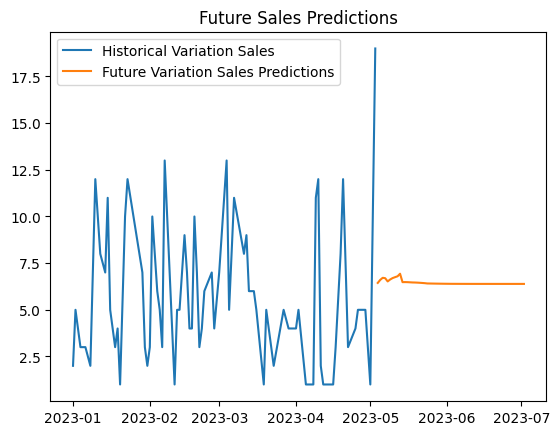

In [11]:
sale2nextmonth=pd.DataFrame(future_predictions,columns=['sale_prediction'], index=future_timestamps)

csv_file_path = 'predictsale2nextmonth_skirt.csv'
# Export the DataFrame to a CSV file
sale2nextmonth.to_csv(csv_file_path)

# Plot the results
plt.plot(data.index, scaler.inverse_transform(data['Sales'].values.reshape(-1, 1)), label='Historical Variation Sales')
plt.plot(future_timestamps, future_predictions, label='Future Variation Sales Predictions')
plt.legend()
plt.title('Future Sales Predictions')
plt.show()

In [12]:
print(sale2nextmonth)

            sale_prediction
2023-05-04         6.440856
2023-05-05         6.602061
2023-05-06         6.714528
2023-05-07         6.694023
2023-05-08         6.520376
2023-05-09         6.623808
2023-05-10         6.700417
2023-05-11         6.749500
2023-05-12         6.796373
2023-05-13         6.933316
2023-05-14         6.481606
2023-05-15         6.485434
2023-05-16         6.481544
2023-05-17         6.473556
2023-05-18         6.465484
2023-05-19         6.462000
2023-05-20         6.455664
2023-05-21         6.447480
2023-05-22         6.437569
2023-05-23         6.427258
2023-05-24         6.411448
2023-05-25         6.409216
2023-05-26         6.406727
2023-05-27         6.404245
2023-05-28         6.401961
2023-05-29         6.399894
2023-05-30         6.397902
2023-05-31         6.396083
2023-06-01         6.394476
2023-06-02         6.393143
2023-06-03         6.392069
2023-06-04         6.391446
2023-06-05         6.390874
2023-06-06         6.390366
2023-06-07         6

In [13]:
sale8month = pd.concat([dataconcate, sale2nextmonth],axis=1)
sale8month

,Item Purchased,Sales,sale_prediction
2023-01-01,Skirt,2.0,NaN
2023-01-02,Skirt,5.0,NaN
2023-01-04,Skirt,3.0,NaN
2023-01-06,Skirt,3.0,NaN
2023-01-08,Skirt,2.0,NaN
...,...,...,...
2023-06-28,NaN,NaN,6.387698
2023-06-29,NaN,NaN,6.387690
2023-06-30,NaN,NaN,6.387683
2023-07-01,NaN,NaN,6.387678


In [14]:
csv_file_path = 'sale6nextmonth_skirt.csv'

# Export the DataFrame to a CSV file
sale8month.to_csv(csv_file_path)

In [15]:
df = pd.read_csv("sale6nextmonth_skirt.csv")

In [16]:
df = df.rename(columns={'Unnamed: 0': 'date'})

In [17]:
df

,date,Item Purchased,Sales,sale_prediction
0,2023-01-01,Skirt,2.0,NaN
1,2023-01-02,Skirt,5.0,NaN
2,2023-01-04,Skirt,3.0,NaN
3,2023-01-06,Skirt,3.0,NaN
4,2023-01-08,Skirt,2.0,NaN
...,...,...,...,...
126,2023-06-28,NaN,NaN,6.387698
127,2023-06-29,NaN,NaN,6.387690
128,2023-06-30,NaN,NaN,6.387683
129,2023-07-01,NaN,NaN,6.387678


In [18]:
for index, row in df.iterrows():
    if pd.isna(df.at[index, "Sales"]):
        df.at[index, "Sales"] = row["sale_prediction"]

In [19]:
df

,date,Item Purchased,Sales,sale_prediction
0,2023-01-01,Skirt,2.000000,NaN
1,2023-01-02,Skirt,5.000000,NaN
2,2023-01-04,Skirt,3.000000,NaN
3,2023-01-06,Skirt,3.000000,NaN
4,2023-01-08,Skirt,2.000000,NaN
...,...,...,...,...
126,2023-06-28,NaN,6.387698,6.387698
127,2023-06-29,NaN,6.387690,6.387690
128,2023-06-30,NaN,6.387683,6.387683
129,2023-07-01,NaN,6.387678,6.387678


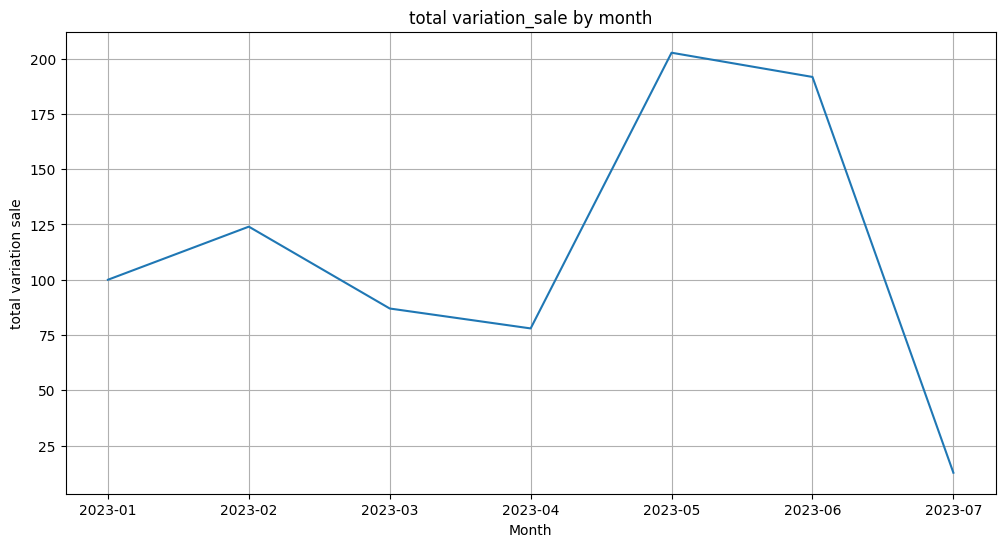

In [20]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv("sale6nextmonth_skirt.csv")
df = df.rename(columns={'Unnamed: 0': 'date'})

for index, row in df.iterrows():
    if pd.isna(df.at[index, "Sales"]):
        df.at[index, "Sales"] = row["sale_prediction"]

# Giả sử bạn có DataFrame 'df' với các cột 'date' và 'variation_sale'
# Cột 'date' có định dạng 'YYYY-MM-DD'

# Tính tổng variation_sale theo tháng
monthly_sales = df.groupby(pd.to_datetime(df['date']).dt.strftime('%Y-%m'))['Sales'].sum().reset_index()

# Đổi tên cột
monthly_sales = monthly_sales.rename(columns={'index': 'month', 'Sales': 'total_variation_sale'})

# Vẽ biểu đồ đường
plt.figure(figsize=(12, 6))
plt.plot(monthly_sales["date"], monthly_sales['total_variation_sale'])
plt.title('total variation_sale by month')
plt.xlabel('Month')
plt.ylabel('total variation sale')
plt.grid()
plt.show()